# Channel 参数学习

这里只演示 Channel：一个细胞、一个 CV、一条带 spike 的目标电压轨迹，每次只训练一个参数。注入电流、Ion、膜电容等保持固定。初值靠近目标，目的是展示接口，不是证明单条轨迹能唯一辨识所有生物参数。

## 哪些参数可以选？

候选项来自 Channel 的构造签名，不再维护可训参数字典。签名可见不等于一定可微；单位、形状和模型原有写法仍然有效。

| 运行类别 | 例子 | 可能的结果 |
|---|---|---|
| 电流系数 | `g_max` | 通道开放且存在驱动力时，通常有梯度 |
| 门控曲线、速率 | `V_sh`、`mMidV`、`alpha`（仅当签名中存在） | 取决于动力学和观测 |
| 温度 | `temp`、`q10`、`temp_ref` | 通过温度因子影响速率；派生 `phi` 随依赖项更新 |
| 独立速率因子 | 显式参数 `phi` | 直接学习自身，不强加温度依赖 |
| 数字指数 | `AHP_De1994.n` | 虽然默认值是整数，浮点指数路径仍可微 |
| 比较式开关 | `gateCurrent != 0` | 两侧值可不同，但对开关的梯度为零 |
| Python 控制流 | `freeze_m_inf`、静态整数配置 | 浮点化或追踪后可能自然报错 |
| 字符串等配置 | `name`、`solver` | 不是数值训练根；保留原有配置路径 |

| 零梯度情形 | 原因 |
|---|---|
| `temp == temp_ref` 时学习 `q10` | 指数为零，温度因子恒为 1 |
| 冻结的 `m_inf` 对 `mMidV` 的梯度 | 模型主动使用 `stop_gradient` |
| 目标没有使用某区域、某参数 | 当前损失没有这条依赖路径 |
| `gateCurrent` 开关 | 比较条件没有连续导数 |

零梯度不是包装失败，也不会自动报错，需要结合模型和训练数据理解。实施与验证范围见 [Channel Learning 记录](../../../docs/specs/2026-09-07-channel-learning.md)。

In [1]:
import os
os.environ["JAX_PLATFORMS"] = "cpu"

from time import perf_counter
import braincell
import brainstate
import braintools
import brainunit as u
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from braincell.filter import AllRegion, RootLocation

DT = 0.025 * u.ms
DURATION = 20.0 * u.ms
EPOCHS = 100
LR = 0.03
print(f"JAX {jax.__version__}; backend={jax.default_backend()}")

JAX 0.8.0; backend=cpu


## 一条目标轨迹

使用 Na/K/Leak 三种通道。所有目标参数取当前 HH Channel 默认值：钠通道 `g_max=120 mS/cm²`、`V_sh=-45 mV`、`temp=309.15 K`（36 °C）。这些是本示例的模型设定，不是声称重现原始 HH 实验温度。

固定电流脉冲：5 ms 开始，持续 10 ms，幅度 0.05 nA。

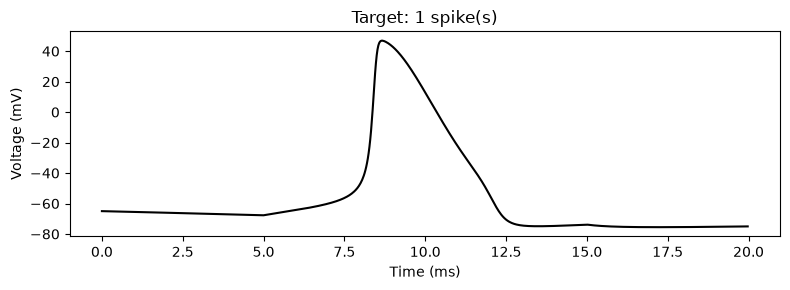

In [2]:
def build_cell():
    soma = braincell.Branch.from_lengths(
        lengths=[20.0] * u.um, radii=[10.0, 10.0] * u.um, type="soma",
    )
    cell = braincell.Cell(
        braincell.Morphology.from_root(soma, name="soma"),
        cv_policy=braincell.CVPerBranch(), pop_size=(1,),
        V_init=-65.0 * u.mV, solver="staggered",
    )
    cell.paint(
        AllRegion(),
        braincell.mech.CableProperty(
            resting_potential=-65.0 * u.mV,
            membrane_capacitance=1.0 * u.uF / u.cm**2,
            axial_resistivity=100.0 * u.ohm * u.cm,
        ),
        braincell.mech.Ion("SodiumFixed", E=50.0 * u.mV),
        braincell.mech.Ion("PotassiumFixed", E=-77.0 * u.mV),
        braincell.mech.Channel("IL", name="leak"),
        braincell.mech.Channel("Na_HH1952", name="na"),
        braincell.mech.Channel("K_HH1952", name="k"),
    )
    cell.place(
        RootLocation(0.5),
        braincell.mech.CurrentClamp(
            delay=5.0 * u.ms, durations=10.0 * u.ms, amplitudes=0.05 * u.nA,
        ),
    )
    cell.soma.record("v", braincell.observe.state("v"))
    return cell


def simulate(cell):
    cell.reset_state()
    return cell.run(dt=DT, duration=DURATION).samples["v"].values.to_decimal(u.mV)[:, 0]


def spike_count(voltage_mv):
    v = np.asarray(voltage_mv)
    return int(np.count_nonzero((v[:-1] < 0.0) & (v[1:] >= 0.0)))


target_cell = build_cell()
target_cell.init_state()
target = brainstate.transform.jit(lambda: simulate(target_cell))()
assert target_cell.n_cv == 1 and spike_count(target) >= 1
# Cell.run records each step's resulting voltage at that step's sample time.
times_ms = np.arange(target.size) * float(DT / u.ms)
plt.figure(figsize=(8, 3))
plt.plot(times_ms, target, color="black")
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (mV)")
plt.title(f"Target: {spike_count(target)} spike(s)")
plt.tight_layout()
plt.show()

## 共用的最小拟合过程

损失只有电压 MSE，spike 数量仅用来验收，不参与求导。每次拟合重新建立模型并 reset 动态状态，只保留训练参数。时间推进由 `Cell.run` 编译，优化迭代使用 `brainstate.transform.for_loop`。

`scale` 训练相对电导；`parameterized` 将无量纲偏移映射回 mV 或 K。这样三个实验的优化尺度都比较直接。

In [3]:
def fit_one(field, source, unit):
    started = perf_counter()
    cell = build_cell()
    cell.channels["na"].trainable(**{field: source})
    cell.init_state()
    parameters = cell.trainables.parameters()
    states = parameters.states()
    assert len(states) == 1 and next(iter(states.values())).value.shape == ()
    predict = brainstate.transform.jit(lambda: simulate(cell))
    initial = np.asarray(predict())
    initial_parameter = float(cell.channels["na"].get(field).to_decimal(unit)[0])

    def loss():
        return jnp.mean((simulate(cell) - target) ** 2)

    gradient = brainstate.transform.grad(loss, grad_states=states, return_value=True)
    optimizer = braintools.optim.Adam(lr=LR)
    optimizer.register_trainable_weights(states)

    @brainstate.transform.jit
    def optimize():
        def step(_):
            gradients, value = gradient()
            optimizer.update(gradients)
            return value
        return brainstate.transform.for_loop(step, jnp.arange(EPOCHS))

    loss_history = np.asarray(optimize())
    fitted = np.asarray(predict())
    initial_mse = float(np.mean((initial - np.asarray(target)) ** 2))
    final_mse = float(np.mean((fitted - np.asarray(target)) ** 2))
    fitted_parameter = float(cell.channels["na"].get(field).to_decimal(unit)[0])
    target_parameter = float(target_cell.channels["na"].get(field).to_decimal(unit)[0])
    elapsed = perf_counter() - started
    assert np.isfinite(loss_history).all() and np.isfinite(fitted).all()
    assert spike_count(fitted) >= 1
    assert final_mse <= 0.1 * initial_mse, (field, initial_mse, final_mse)

    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    axes[0].plot(times_ms, target, color="black", label="Target")
    axes[0].plot(times_ms, initial, color="#a76637", alpha=0.7, label="Initial")
    axes[0].plot(times_ms, fitted, color="#168b83", linestyle="--", label="Fitted")
    axes[0].set(xlabel="Time (ms)", ylabel="Voltage (mV)", title=field)
    axes[0].legend(fontsize=8)
    axes[1].semilogy(np.arange(EPOCHS), loss_history, color="#168b83")
    axes[1].scatter([EPOCHS], [final_mse], color="black", s=15)
    axes[1].set(xlabel="Adam update", ylabel="Voltage MSE (mV²)")
    fig.tight_layout()
    plt.show()
    display(Markdown(
        "| 参数 | 初值 | 目标 | 拟合 | 初始 MSE | 最终 MSE | 耗时（含编译） |\n"
        "|---|---:|---:|---:|---:|---:|---:|\n"
        f"| {field} ({unit}) | {initial_parameter:.6g} | {target_parameter:.6g} | "
        f"{fitted_parameter:.6g} | {initial_mse:.6g} | {final_mse:.6g} | {elapsed:.2f} s |"
    ))
    return {"field": field, "initial_mse": initial_mse, "final_mse": final_mse,
            "seconds": elapsed, "spikes": spike_count(fitted)}


### 1. 电流幅度：只学 `g_max`

电导从目标值的 90% 出发。这里学习的是通道电流系数，不是注入电流；电压和门控状态仍由模型共同决定。

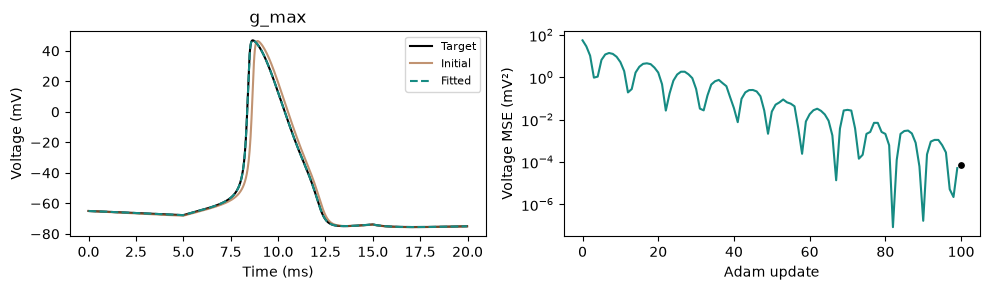

| 参数 | 初值 | 目标 | 拟合 | 初始 MSE | 最终 MSE | 耗时（含编译） |
|---|---:|---:|---:|---:|---:|---:|
| g_max (mS / cm^2) | 108 | 120 | 119.966 | 55.9342 | 7.09192e-05 | 5.63 s |

In [4]:
conductance_result = fit_one(
    "g_max",
    braincell.trainable.scale(brainstate.nn.Param(0.9), name="na_conductance_scale"),
    u.mS / u.cm**2,
)

### 2. 门控曲线与速率：只学 `V_sh`

`V_sh` 同时进入钠通道的 alpha/beta 速率函数。初值比目标高 1 mV，其余所有参数都保持目标值。

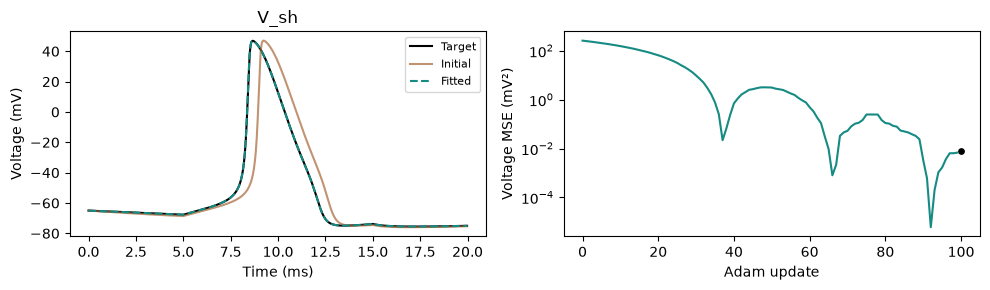

| 参数 | 初值 | 目标 | 拟合 | 初始 MSE | 最终 MSE | 耗时（含编译） |
|---|---:|---:|---:|---:|---:|---:|
| V_sh (mV) | -44 | -45 | -45.0055 | 258.324 | 0.00785799 | 6.27 s |

In [5]:
def shifted_voltage(ctx, delta):
    return -45.0 * u.mV + delta * u.mV


voltage_shift_result = fit_one(
    "V_sh",
    braincell.trainable.parameterized(shifted_voltage, delta=brainstate.nn.Param(1.0)),
    u.mV,
)

### 3. 温度：只学 `temp`

这里只改变钠通道温度，不改变钾通道或整个细胞的温度。初值为 35 °C，目标为 36 °C。

依赖关系是 `temp → q10 ** ((temp - temp_ref) / (10 K)) → 门控速率 → 电压`。
HH 通道通过门控辅助函数读取温度因子；部分 sodium Markov 通道则通过动态 `phi` 属性读取。显式独立 `phi` 参数仍保持独立。

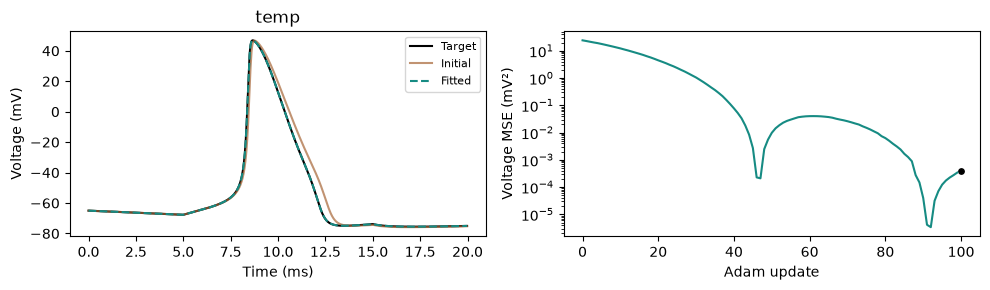

| 参数 | 初值 | 目标 | 拟合 | 初始 MSE | 最终 MSE | 耗时（含编译） |
|---|---:|---:|---:|---:|---:|---:|
| temp (K) | 308.15 | 309.15 | 309.145 | 24.2734 | 0.000379125 | 5.58 s |

In [6]:
def shifted_temperature(ctx, delta):
    return u.celsius2kelvin(36.0) + delta * u.kelvin


temperature_result = fit_one(
    "temp",
    braincell.trainable.parameterized(shifted_temperature, delta=brainstate.nn.Param(-1.0)),
    u.kelvin,
)

## 零梯度与自然报错的实际检查

下面通过同一训练接口检查 `q10` 和 `gateCurrent`。参考温度时对 `q10` 的梯度为零；温度提高 10 K 后梯度非零。`gateCurrent` 的开关值改变电流，但两个位置的梯度都为零。随后演示字符串、错误单位和形状被拒绝。异常会被捕获，整本 notebook 可以顺序执行。

`gateCurrent` 在这里仅作固定电压下的计算图检查。现有公式的开启分支会给出很大的电流值，本次没有校准或修改其幅值，也没有用该分支生成三个拟合的目标数据。

In [7]:
probe = build_cell()
probe.channels["na"].trainable(q10=braincell.trainable.parameter(group_by="all", name="q10"))
probe.init_state()
na_layout = next(layout for layout in probe.runtime.layouts
                 if probe.runtime.layout_mechanisms[layout.id].instance_name == "na")
na = probe.runtime.get_runtime_node(na_layout.id)


def temperature_factor():
    probe.trainables.materialize()
    return na.gate_phi(na._iter_gates()[0]).sum()


gradient = brainstate.transform.jit(brainstate.transform.grad(
    temperature_factor, grad_states=probe.trainables.parameters().states(),
))
zero = float(gradient()["q10"])
probe.channels["na"].set(temp=u.celsius2kelvin(46.0))
nonzero = float(gradient()["q10"])
assert zero == 0.0 and nonzero > 0.0
rows = [f"| q10: temp == temp_ref | gradient = {zero:g} |",
        f"| q10: temp == temp_ref + 10 K | gradient = {nonzero:g} |"]

switch_cell = build_cell()
switch_cell.paint(AllRegion(), braincell.mech.Channel("Kv1p1_MA2025_BC", name="switch"))
switch_cell.channels["switch"].trainable(
    gateCurrent=braincell.trainable.parameter(group_by="all", name="flag"),
)
switch_cell.init_state()
switch_layout = next(layout for layout in switch_cell.runtime.layouts
                     if switch_cell.runtime.layout_mechanisms[layout.id].instance_name == "switch")
switch_node = switch_cell.runtime.get_runtime_node(switch_layout.id)
potassium = braincell.IonInfo(E=-77.0 * u.mV, Ci=140.0 * u.mM, Co=5.0 * u.mM, valence=1)


def switch_current():
    switch_cell.trainables.materialize()
    return switch_node.current(-30.0 * u.mV, potassium).to_decimal(u.mA / u.cm**2).sum()


switch_parameters = switch_cell.trainables.parameters()
switch_gradient = brainstate.transform.jit(brainstate.transform.grad(
    switch_current, grad_states=switch_parameters.states(), return_value=True,
))
grad_off, current_off = switch_gradient()
switch_parameters.set_physical_values({"flag": 1.0})
grad_on, current_on = switch_gradient()
assert float(grad_off["flag"]) == float(grad_on["flag"]) == 0.0
assert float(current_off) != float(current_on)
rows.extend([f"| gateCurrent = 0 | gradient = 0; I = {float(current_off):.6g} mA/cm² |",
             f"| gateCurrent = 1 | gradient = 0; I = {float(current_on):.6g} mA/cm² |"])

# These are independent registration checks, not repeated model time steps.
for field, value in [("name", "text"), ("g_max", 1.0),
                     ("V_sh", 1.0 * u.kelvin), ("temp", np.ones((2, 3)) * u.kelvin)]:
    bad_cell = build_cell()
    try:
        bad_cell.channels["na"].trainable(**{
            field: braincell.trainable.parameter(value, group_by="all"),
        })
    except (TypeError, ValueError) as error:
        description = str(value).replace("\n", " ")
        rows.append(f"| {field}: {description} | {type(error).__name__} |")
        assert not bad_cell.trainables.bindings()
    else:
        raise AssertionError(f"{field} unexpectedly accepted the invalid source")
display(Markdown("| 检查 | 实际结果 |\n|---|---|\n" + "\n".join(rows)))

| 检查 | 实际结果 |
|---|---|
| q10: temp == temp_ref | gradient = 0 |
| q10: temp == temp_ref + 10 K | gradient = 1 |
| gateCurrent = 0 | gradient = 0; I = -1.86135e-05 mA/cm² |
| gateCurrent = 1 | gradient = 0; I = -7.92288e+13 mA/cm² |
| name: text | ValueError |
| g_max: 1.0 | TypeError |
| V_sh: 1. K | ValueError |
| temp: [[1. 1. 1.]  [1. 1. 1.]] K | ValueError |

## 区域选择与边界

此 notebook 的三个拟合只有一个 CV。多区域模型沿用原有选择接口，例如 `cell.soma.channels["na"].trainable(...)` 或 `cell[0].branch[1].channels["na"].trainable(...)`。

- `group_by="all"` 只共享**选中区域**内的训练根，不会把未选区域的参数一起更新。
- `population`、`cv`、`row` 分别指定共享方式；不同区域也可以绑定同一个显式 `nn.Param`。
- 未选区域的参数不变，不代表其电压不变：区域之间仍然电耦合。
- 参数没有在声明时传入，也可以先读签名默认值、用 `.set()` 覆盖，再注册训练；注册后应更新训练根，不能再用 `.set()` 覆盖同一绑定。

这些例子只说明局部可学习性和接口用法，不对全局收敛、单轨迹可辨识性或任意参数组合做保证。

In [8]:
results = [conductance_result, voltage_shift_result, temperature_result]
display(Markdown(
    "| 拟合参数 | 最终/初始 MSE | 拟合 spike 数 |\n|---|---:|---:|\n" +
    "\n".join(f"| {r['field']} | {r['final_mse'] / r['initial_mse']:.4g} | {r['spikes']} |"
              for r in results)
))
print(f"Three fits: {sum(r['seconds'] for r in results):.2f} s including compilation")

| 拟合参数 | 最终/初始 MSE | 拟合 spike 数 |
|---|---:|---:|
| g_max | 1.268e-06 | 1 |
| V_sh | 3.042e-05 | 1 |
| temp | 1.562e-05 | 1 |

Three fits: 17.48 s including compilation
